# Harmful Text Detection Model Training  
Multi-label text classification for detecting toxic content in user-generated text.

**Dataset:** Jigsaw Toxic Comment Classification (HuggingFace), Civil Comment Jigsaaw Google (HuggingFace), Synthetic Professional Toxicity

**Models:** BERT · RoBERTa · DistilBERT

**Labels:** Toxicity · Obscene · Threat · Insult · Identity Hate

## 0. Install Dependencies

In [1]:
# install everything we need — transformer models, torch, sklearn, the usual suspects
# the second line upgrades torch to use CUDA 12.1 if we're on a GPU machine
!pip install -q transformers torch scikit-learn pandas numpy joblib tqdm datasets
!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121

## 1. Imports & Device Check

In [2]:
# standard imports — nothing fancy, just pulling in what the rest of the notebook needs
# tqdm gives us progress bars, datasets is the HuggingFace library for easy data loading
# sklearn is used later for all our evaluation metrics
# we suppress warnings at the bottom because transformers tends to be noisy
import pandas as pd
import numpy as np
import torch
import re
import json as json_lib
import joblib
import os
import shutil
import zipfile
import datetime
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, accuracy_score,
    precision_score, recall_score, f1_score, jaccard_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, confusion_matrix,
)
from matplotlib.patches import FancyArrowPatch
import time

warnings.filterwarnings('ignore')
print('Imports successful!')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
if torch.cuda.is_available():
    print(f'CUDA: {torch.version.cuda}')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Compute capability: {torch.cuda.get_device_capability(0)}')
    try:
        x = torch.randn(10, 10).cuda()
        y = x @ x
        print('GPU computation: OK')
    except Exception as e:
        print(f'GPU computation FAILED: {e}')

Imports successful!
PyTorch: 2.10.0+cu128
Device: cuda
CUDA: 12.8
GPU: Tesla T4
Compute capability: (7, 5)
GPU computation: OK


## 2. Data Loading and Preprocessing

In [3]:
# this section handles loading the training data from two possible sources:
# (1) a pre-built augmented CSV that we already prepared, or
# (2) the raw Jigsaw dataset from HuggingFace as a fallback
#
# LABEL_SCHEMA maps each toxic category to an index — this order matters everywhere
# Note: severe_toxic is merged into toxicity (index 0) since they overlap heavily
LABEL_SCHEMA = {
    "toxicity": 0,
    "obscene": 1,
    "threat": 2,
    "insult": 3,
    "identity_hate": 4,
}
REVERSE_LABEL_SCHEMA = {v: k for k, v in LABEL_SCHEMA.items()}
LABEL_NAMES = list(LABEL_SCHEMA.keys())
NUM_LABELS = len(LABEL_SCHEMA)

def load_jigsaw_dataset():
    """Load Jigsaw dataset from HuggingFace."""
    print("Loading Jigsaw dataset from HuggingFace...")
    dataset = load_dataset(
        "thesofakillers/jigsaw-toxic-comment-classification-challenge",
        split="train"
    )
    df = dataset.to_pandas()

    if 'comment_text' in df.columns:
        df = df.rename(columns={'comment_text': 'text'})

    col_to_schema = {
        'toxic': 'toxicity',
        'severe_toxic': 'toxicity',  # merged — severe_toxic OR toxic → toxicity
        'obscene': 'obscene',
        'threat': 'threat',
        'insult': 'insult',
        'identity_hate': 'identity_hate',
    }
    available_cols = [c for c in col_to_schema if c in df.columns]

    print(f"\nRaw dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nSample (raw, before label encoding):")
    print(df[['text'] + available_cols].head(5).to_string())
    print(f"\nRaw label value counts:")
    for col in available_cols:
        pos = df[col].sum()
        print(f"  {col:<20} 1s: {pos:>6,}  ({pos/len(df)*100:.2f}%)")

    def make_label_vector(row):
        vec = [0.0] * NUM_LABELS
        for col in available_cols:
            if row[col] == 1:
                vec[LABEL_SCHEMA[col_to_schema[col]]] = 1.0
        return vec

    df['labels'] = df[available_cols].apply(make_label_vector, axis=1)
    df['source'] = 'jigsaw'

    print(f"\nAfter label encoding sample rows:")
    print(df[['text', 'labels']].head(5).to_string())
    print(f"\nSample clean vector  : {df['labels'].iloc[0]}")
    flagged = df[df['labels'].apply(lambda x: any(v > 0 for v in x))]
    print(f"Sample flagged vector: {flagged['labels'].iloc[0]}")
    print(f"Sample flagged text  : {flagged['text'].iloc[0][:100]}...")

    return df[['text', 'labels', 'source']].copy()

def load_augmented_csv(csv_path):
    """Load pre-built augmented dataset from CSV and reconstruct the labels list column."""
    print(f"Loading augmented dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    # Reconstruct the labels list column expected by the rest of this notebook
    label_names = list(LABEL_SCHEMA.keys())
    df['labels'] = df[label_names].astype(float).values.tolist()
    df = df[['text', 'labels', 'source']].copy()
    df = df.dropna(subset=['text'])
    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'].str.len() > 10].reset_index(drop=True)
    print(f"Loaded {len(df):,} rows")
    return df

augmented_csv = None

# 1. Kaggle
if os.path.exists('/kaggle/input'):
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if 'toxicity_augmented' in filename.lower() and filename.endswith('.csv'):
                augmented_csv = os.path.join(dirname, filename)
                print(f"Found augmented dataset (Kaggle): {augmented_csv}")
                break

# 2. Local / Colab — same directory as notebook
if augmented_csv is None:
    _nb_dir = os.path.dirname(os.path.abspath('TRAIN_MODEL.ipynb'))
    for candidate in [
        os.path.join(_nb_dir, 'toxicity_augmented.csv'),
        'toxicity_augmented.csv',  # cwd fallback
    ]:
        if os.path.exists(candidate):
            augmented_csv = os.path.abspath(candidate)
            print(f"Found augmented dataset (local): {augmented_csv}")
            break

if augmented_csv:
    jigsaw_df = load_augmented_csv(augmented_csv)
else:
    print("Augmented CSV not found — loading Jigsaw from HuggingFace")
    jigsaw_df = load_jigsaw_dataset()

print(f"\nFinal DataFrame: {len(jigsaw_df):,} samples, {len(jigsaw_df.columns)} columns")
print(jigsaw_df.head(3).to_string())


Found augmented dataset (Kaggle): /kaggle/input/datasets/angelicasutiwhiharto/toxicity-detection-dataset/toxicity_augmented.csv
Loading augmented dataset from: /kaggle/input/datasets/angelicasutiwhiharto/toxicity-detection-dataset/toxicity_augmented.csv
Loaded 28,937 rows

Final DataFrame: 28,937 samples, 3 columns
                                                                                                                                                                                                                                                                                                                                                                                                                                               text                     labels  source
0  Where are all these rules coming from? Do you just make them up? What does controversial have to do with anything? Either it is accurate or it is not. I have cited Wikipedia's own definition of hate groups. Co

In [4]:
# quick sanity check on the full dataset before we start touching anything
# shows label distribution, imbalance ratio, and how many samples have multiple labels
# useful to catch any weirdness in the data early
def print_label_stats(df, name='Dataset'):
    total = len(df)
    has_any = df['labels'].apply(lambda x: any(v > 0 for v in x))
    n_toxic = has_any.sum()
    n_clean = total - n_toxic

    print(f'  {name}')
    print(f'  Total samples : {total:,}')
    print(f'  Clean (no label): {n_clean:,} ({n_clean/total*100:.2f}%)')
    print(f'  Flagged (any label): {n_toxic:,} ({n_toxic/total*100:.2f}%)')
    print(f'  Imbalance ratio: 1 toxic per {n_clean/n_toxic:.1f} clean')
    print(f'  {"─"*53}')
    print(f'  {"Label":<20} {"Count":>8} {"% of total":>12} {"% of flagged":>14}')
    print(f'  {"─"*53}')
    label_counts = {REVERSE_LABEL_SCHEMA[i]: 0 for i in range(NUM_LABELS)}
    for label_vec in df['labels']:
        for i, val in enumerate(label_vec):
            if val == 1.0:
                label_counts[REVERSE_LABEL_SCHEMA[i]] += 1
    for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
        pct_total   = count / total * 100
        pct_flagged = count / n_toxic * 100 if n_toxic > 0 else 0
        print(f'  {label:<20} {count:>8,} {pct_total:>11.2f}% {pct_flagged:>13.2f}%')
    print(f'  {"─"*53}')
    multi = df['labels'].apply(lambda x: sum(v > 0 for v in x))
    print(f'  Avg labels per flagged sample: {multi[multi>0].mean():.2f}')
    print(f'  Samples with 2+ labels: {(multi>=2).sum():,}')
    print(f'  Samples with 3+ labels: {(multi>=3).sum():,}')

print_label_stats(jigsaw_df, 'FULL DATASET (before split)')

  FULL DATASET (before split)
  Total samples : 28,937
  Clean (no label): 15,000 (51.84%)
  Flagged (any label): 13,937 (48.16%)
  Imbalance ratio: 1 toxic per 1.1 clean
  ─────────────────────────────────────────────────────
  Label                   Count   % of total   % of flagged
  ─────────────────────────────────────────────────────
  toxicity               13,145       45.43%         94.32%
  insult                  6,590       22.77%         47.28%
  identity_hate           6,423       22.20%         46.09%
  obscene                 4,197       14.50%         30.11%
  threat                    711        2.46%          5.10%
  ─────────────────────────────────────────────────────
  Avg labels per flagged sample: 2.23
  Samples with 2+ labels: 10,799
  Samples with 3+ labels: 4,970


In [5]:
# the Jigsaw dataset is heavily imbalanced — ~90% clean, ~10% toxic
# we use all available rows (13,937 toxic + 15,000 clean) — no subsampling needed
#
# rare labels (threat, identity_hate) are prioritized during subsampling
# so we don't accidentally throw away the minority classes we care most about
# TARGET_SIZE is derived from the actual dataset so we never request more rows than exist.
# With the augmented CSV (13,937 toxic + 15,000 clean = 28,937 total) the old hard-coded
# 30,000 target caused a crash because clean_df only has 15,000 rows.
TARGET_SIZE = len(jigsaw_df)

label_cols = list(LABEL_SCHEMA.keys())
jigsaw_df['has_any_label'] = jigsaw_df['labels'].apply(lambda x: any(v > 0 for v in x))

toxic_df = jigsaw_df[jigsaw_df['has_any_label']].copy()
clean_df = jigsaw_df[~jigsaw_df['has_any_label']].copy()

print(f"Dataset composition:")
print(f"  Toxic rows: {len(toxic_df):>7,}  ({len(toxic_df)/len(jigsaw_df)*100:5.2f}%)")
print(f"  Clean rows: {len(clean_df):>7,}  ({len(clean_df)/len(jigsaw_df)*100:5.2f}%)")
print(f"  Total     : {len(jigsaw_df):>7,}")

# Cap each group at what's available — keeps all rare-label rows intact
n_toxic_target = len(toxic_df)
n_clean_target = len(clean_df)

rare_labels = ['threat', 'identity_hate']
rare_idx    = [LABEL_SCHEMA[l] for l in rare_labels]

def rarity_score(label_list):
    return sum(label_list[i] for i in rare_idx)

toxic_df['rarity_score'] = toxic_df['labels'].apply(rarity_score)
toxic_df = toxic_df.sort_values('rarity_score', ascending=False)

rare_rows   = toxic_df[toxic_df['rarity_score'] > 0]
common_rows = toxic_df[toxic_df['rarity_score'] == 0]

# keep all toxic rows — no need to cut since we're using the full dataset
sampled_toxic = toxic_df.copy()
print(f"\n  Rare-label rows  : {len(rare_rows):,}")
print(f"  Common toxic rows: {len(common_rows):,}")

sampled_clean = clean_df.sample(n=n_clean_target, random_state=42)
jigsaw_df = pd.concat([sampled_toxic, sampled_clean]).sample(frac=1, random_state=42).reset_index(drop=True)
jigsaw_df = jigsaw_df.drop(columns=['has_any_label', 'rarity_score'], errors='ignore')

print(f"\nFinal dataset:")
print(f"  Toxic rows: {n_toxic_target:>7,}  ({n_toxic_target/TARGET_SIZE*100:5.2f}%)")
print(f"  Clean rows: {n_clean_target:>7,}  ({n_clean_target/TARGET_SIZE*100:5.2f}%)")
print(f"  Total     : {len(jigsaw_df):>7,}")

print(f"\nLabel distribution after subsampling:")
for col_name, col_idx in LABEL_SCHEMA.items():
    count = jigsaw_df['labels'].apply(lambda x: x[col_idx]).sum()
    pct = count / len(jigsaw_df) * 100
    print(f"  {col_name:<20} {count:>5,.0f}  ({pct:5.2f}%)")

Dataset composition:
  Toxic rows:  13,937  (48.16%)
  Clean rows:  15,000  (51.84%)
  Total     :  28,937

  Rare-label rows  : 6,937
  Common toxic rows: 7,000

Final dataset:
  Toxic rows:  13,937  (48.16%)
  Clean rows:  15,000  (51.84%)
  Total     :  28,937

Label distribution after subsampling:
  toxicity             13,145  (45.43%)
  obscene              4,197  (14.50%)
  threat                 711  ( 2.46%)
  insult               6,590  (22.77%)
  identity_hate        6,423  (22.20%)


In [6]:
# stratified train/val/test split — 70% / 15% / 15%
# stratifying on has_toxic ensures the toxic/clean ratio stays consistent across splits
# this prevents the val or test set from being accidentally cleaner than training
jigsaw_df['has_toxic'] = jigsaw_df['labels'].apply(lambda x: int(any(v > 0 for v in x)))

train_val, test_df = train_test_split(
    jigsaw_df, test_size=0.15, random_state=42,
    stratify=jigsaw_df['has_toxic']
)
train_df, val_df = train_test_split(
    train_val, test_size=0.15/0.85, random_state=42,
    stratify=train_val['has_toxic']
)

for _df in [jigsaw_df, train_df, val_df, test_df]:
    _df.drop(columns=['has_toxic'], inplace=True, errors='ignore')

print(f'Split sizes:')
print(f'  Train : {len(train_df):>6,} ({len(train_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  Val   : {len(val_df):>6,} ({len(val_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  Test  : {len(test_df):>6,} ({len(test_df)/len(jigsaw_df)*100:.1f}%)')

print_label_stats(train_df, 'TRAIN SPLIT')
print_label_stats(val_df,   'VAL SPLIT')
print_label_stats(test_df,  'TEST SPLIT')

print('\nToxic ratio consistency check (should be ~equal):')
for name, df in [('Full', jigsaw_df), ('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    ratio = df['labels'].apply(lambda x: any(v > 0 for v in x)).mean()
    print(f'  {name:<6}: {ratio:.4f} ({ratio*100:.2f}% toxic)')

Split sizes:
  Train : 20,255 (70.0%)
  Val   :  4,341 (15.0%)
  Test  :  4,341 (15.0%)
  TRAIN SPLIT
  Total samples : 20,255
  Clean (no label): 10,500 (51.84%)
  Flagged (any label): 9,755 (48.16%)
  Imbalance ratio: 1 toxic per 1.1 clean
  ─────────────────────────────────────────────────────
  Label                   Count   % of total   % of flagged
  ─────────────────────────────────────────────────────
  toxicity                9,217       45.50%         94.48%
  insult                  4,659       23.00%         47.76%
  identity_hate           4,446       21.95%         45.58%
  obscene                 2,956       14.59%         30.30%
  threat                    500        2.47%          5.13%
  ─────────────────────────────────────────────────────
  Avg labels per flagged sample: 2.23
  Samples with 2+ labels: 7,576
  Samples with 3+ labels: 3,524
  VAL SPLIT
  Total samples : 4,341
  Clean (no label): 2,250 (51.83%)
  Flagged (any label): 2,091 (48.17%)
  Imbalance ratio: 

## 3. Text Preprocessing & Tokenization

In [7]:
# text preprocessing before tokenization
# we strip URLs, HTML tags, @mentions, and hashtags — they're noise for toxicity detection
# make_hf_dataset converts our pandas DataFrame into a HuggingFace Dataset
# and tokenizes it in batches for efficiency
# max_length=128 is the default; longer sequences get truncated
class TextPreprocessor:
    """Basic text cleaning — remove URLs, HTML, mentions, hashtags."""
    @staticmethod
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^\w\s.,!?-]', '', text)
        return re.sub(r'\s+', ' ', text).strip()


def make_hf_dataset(df, tokenizer, max_length=128):
    """
    Convert a pandas DataFrame to a HuggingFace Dataset and tokenize it.
    max_length is configurable per model.
    """
    preprocessor = TextPreprocessor()
    cleaned_texts = [preprocessor.clean_text(t) for t in df['text'].tolist()]

    hf_ds = Dataset.from_dict({
        'text':   cleaned_texts,
        'labels': df['labels'].tolist(),
    })

    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=max_length)

    hf_ds = hf_ds.map(tokenize, batched=True)
    hf_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return hf_ds

preprocessor = TextPreprocessor()
sample = "This is TOXIC!!! Visit www.spam.com @troll #hate"
print(f"Original : {sample}")
print(f"Cleaned  : {preprocessor.clean_text(sample)}")

Original : This is TOXIC!!! Visit www.spam.com @troll #hate
Cleaned  : This is TOXIC!!! Visit


## 4. Metrics, Weighted Trainer & Training Functions

### Why Weighted BCE?

This is a **multi-label classification** problem — each piece of text can have more than one label at once (e.g. both `threat` and `insult`). The standard loss function for this setup is **Binary Cross-Entropy (BCE)**, which treats each label independently as its own yes/no question.

The problem is that some labels are very rare. In `toxicity_augmented.csv`, only 711 out of 28,937 rows are labelled `threat`. If the model just predicts "not a threat" for every single row, it gets that label right 97.5% of the time — so the loss stays low even though the model has learned nothing useful. BCE on its own does not penalize that behaviour.

**Weighted BCE** fixes this by multiplying the loss for positive (= label present) examples by a weight > 1. A higher weight means the model is penalized much harder for missing that label, forcing it to pay attention even when positives are rare.

### Where Do the Weights Come From?

For each label we count how many negative examples exist for every one positive example — the **neg:pos ratio**:

| Label | Positives | Negatives | Neg:pos ratio |
|---|---|---|---|
| toxicity | 13,145 | 15,792 | 1.2x |
| obscene | 4,197 | 24,740 | 5.9x |
| threat | 711 | 28,226 | 39.7x |
| insult | 6,590 | 22,347 | 3.4x |
| identity_hate | 6,423 | 22,514 | 3.5x |

The neg:pos ratio is a natural starting point for the weight — but using it directly would set `threat` to **39.7**, which is far too aggressive. The model would over-focus on threat and sacrifice precision for all other labels.

Instead we apply **square-root dampening**: `pos_weight = sqrt(neg/pos ratio)`. The square root compresses large ratios into a moderate range that still reflects relative rarity without over-correcting:

| Label | Neg:pos ratio | sqrt(neg/pos) | Final weight |
|---|---|---|---|
| toxicity | 1.2x | √1.2 = 1.1 | **1.1** |
| obscene | 5.9x | √5.9 = 2.4 | **2.4** |
| threat | 39.7x | √39.7 = 6.3 | **6.3** |
| insult | 3.4x | √3.4 = 1.8 | **1.8** |
| identity_hate | 3.5x | √3.5 = 1.9 | **1.9** |

### How It Is Implemented

HuggingFace `Trainer` uses Cross-Entropy loss by default. We subclass it and override only `compute_loss` to swap in `BCEWithLogitsLoss` with the `pos_weight` tensor. Everything else — the training loop, optimizer, scheduler, logging, early stopping — stays unchanged from HuggingFace.

**Key design decisions:**
- Threshold tuning: fixed 0.5 during training (for early stopping signal only); per-label F1-optimal threshold found via grid search (0.10–0.90, step 0.02) on val set after training
- Section 6b adds an ensemble benchmark (mean probability aggregation across all three models, no retraining)


In [8]:
# POS_WEIGHTS: one weight per label, applied inside WeightedBCETrainer
# formula: sqrt(neg_count / pos_count) — dampens extreme ratios (threat would be 39.7 raw)
# full derivation and rationale are documented in the markdown cell above
#
# WeightedBCETrainer: subclasses HuggingFace Trainer, overrides compute_loss only
# swaps default CrossEntropyLoss → BCEWithLogitsLoss(pos_weight=POS_WEIGHTS)
#
# compute_metrics: fixed 0.5 threshold during training — used only for early stopping signal
# final evaluation uses per-label F1-optimal thresholds from find_optimal_thresholds
#
# find_optimal_thresholds: grid search 0.10–0.90 step 0.02 on val set, one threshold per label
#
# build_rich_metrics: assembles the full metrics dict saved to metrics.json
# includes macro F1, per-label breakdown, confusion matrix, AUC, MCC, Cohen kappa, etc.
POS_WEIGHTS = torch.tensor([1.1, 2.4, 6.3, 1.8, 1.9])  # toxicity, obscene, threat, insult, identity_hate

class WeightedBCETrainer(Trainer):
    """
    Custom Trainer replacing default BCE with pos-weighted BCE.
    Addresses severe label imbalance in Jigsaw. Higher weights for rare labels
    (threat, identity_hate) after v5 analysis showed underperformance attributable
    to insufficient loss signal. Dataset uses 5 labels (no severe_toxicity).
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels').float()
        outputs = model(**inputs)
        logits = outputs.logits
        pw = POS_WEIGHTS.to(logits.device)
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pw)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    """
    Fixed 0.5 threshold metrics for early stopping signal during training.
    Final evaluation uses per-label F1-optimized thresholds.
    """
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)
    labels = labels.astype(int)
    per_label_acc = (preds == labels).mean(axis=0).mean()
    subset_acc    = (preds == labels).all(axis=1).mean()
    return {
        'f1':              f1_score(labels, preds, average='macro', zero_division=0),
        'precision':       precision_score(labels, preds, average='macro', zero_division=0),
        'recall':          recall_score(labels, preds, average='macro', zero_division=0),
        'jaccard':         jaccard_score(labels, preds, average='micro', zero_division=0),
        'hamming_loss':    hamming_loss(labels, preds),
        'accuracy':        float(per_label_acc),
        'subset_accuracy': float(subset_acc),
    }


def compute_per_label_metrics(probs, labels, thresholds=None):
    """Compute per-label F1, precision, recall using provided thresholds."""
    if thresholds is None:
        thresholds = {lbl: 0.5 for lbl in LABEL_NAMES}
    preds = np.zeros_like(probs, dtype=int)
    for i, lbl in enumerate(LABEL_NAMES):
        preds[:, i] = (probs[:, i] > thresholds.get(lbl, 0.5)).astype(int)
    result = {}
    for i, lbl in enumerate(LABEL_NAMES):
        result[lbl] = {
            'f1':        round(float(f1_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'precision': round(float(precision_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'recall':    round(float(recall_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'threshold': round(thresholds.get(lbl, 0.5), 3),
        }
    return result


def _threshold_search(probs, labels, label_names=None):
    """
    Shared grid-search: find threshold per label maximising F1.
    Grid: 0.10 to 0.90, step 0.02 (wider and finer than v5).
    """
    if label_names is None:
        label_names = LABEL_NAMES
    best_thresholds = {}
    print(f"  {'Label':<20} {'Threshold':>10} {'F1':>8} {'Precision':>10} {'Recall':>8}")
    print(f"  {'─'*58}")
    for i, label in enumerate(label_names):
        best_t, best_f1, best_prec, best_rec = 0.5, 0.0, 0.0, 0.0
        for t in np.arange(0.10, 0.90, 0.02):
            p    = (probs[:, i] > t).astype(int)
            f1   = f1_score(labels[:, i], p, zero_division=0)
            prec = precision_score(labels[:, i], p, zero_division=0)
            rec  = recall_score(labels[:, i], p, zero_division=0)
            if f1 > best_f1:
                best_f1, best_prec, best_rec, best_t = f1, prec, rec, float(t)
        best_thresholds[label] = best_t
        print(f"  {label:<20} {best_t:>10.3f} {best_f1:>8.4f} {best_prec:>10.4f} {best_rec:>8.4f}")
    return best_thresholds


def find_optimal_thresholds(trainer, val_dataset):
    """
    Grid-search threshold per label maximising F1 on the val set.
    Called after each model finishes training.
    """
    print('\nFinding F1-optimal per-label thresholds on val set...')
    preds_output = trainer.predict(val_dataset)
    probs  = torch.sigmoid(torch.tensor(preds_output.predictions)).numpy()
    labels = preds_output.label_ids.astype(int)
    return _threshold_search(probs, labels)


def find_optimal_thresholds_from_probs(probs, labels):
    """
    Same grid-search but accepts raw probs + labels directly.
    Used by the ensemble benchmark (probs already averaged before calling).
    """
    print('\nFinding F1-optimal thresholds on ensemble val probs...')
    return _threshold_search(probs, labels)


def compute_metrics_with_thresholds(thresholds):
    """Returns a compute_metrics function using per-label thresholds."""
    def _compute(eval_pred):
        logits, labels = eval_pred
        probs  = torch.sigmoid(torch.tensor(logits)).numpy()
        labels = labels.astype(int)
        preds  = np.zeros_like(probs, dtype=int)
        for i, label in enumerate(LABEL_NAMES):
            preds[:, i] = (probs[:, i] > thresholds.get(label, 0.5)).astype(int)
        per_label_acc = (preds == labels).mean(axis=0).mean()
        subset_acc    = (preds == labels).all(axis=1).mean()
        return {
            'f1':              f1_score(labels, preds, average='macro',  zero_division=0),
            'precision':       precision_score(labels, preds, average='macro',  zero_division=0),
            'recall':          recall_score(labels, preds, average='macro',  zero_division=0),
            'jaccard':         jaccard_score(labels, preds, average='micro',  zero_division=0),
            'hamming_loss':    hamming_loss(labels, preds),
            'accuracy':        float(per_label_acc),
            'subset_accuracy': float(subset_acc),
        }
    return _compute


def build_rich_metrics(probs, labels_array, thresholds, model_name, model_type,
                       train_samples, test_samples, training_date, train_time_min,
                       training_history, per_label_metrics_dict,
                       label_schema, reverse_schema, best_thresholds):
    preds = np.zeros_like(probs, dtype=int)
    for i, lbl in enumerate(LABEL_NAMES):
        preds[:, i] = (probs[:, i] > thresholds.get(lbl, 0.5)).astype(int)
    labels = labels_array.astype(int)
    y_true_bin = labels.any(axis=1).astype(int)
    y_pred_bin = preds.any(axis=1).astype(int)
    y_prob_bin = probs.max(axis=1)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).ravel()
    acc_bin  = accuracy_score(y_true_bin, y_pred_bin)
    prec_bin = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec_bin  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1_bin   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    try:
        auc = float(roc_auc_score(y_true_bin, y_prob_bin))
    except Exception:
        auc = 0.0
    try:
        mcc = float(matthews_corrcoef(y_true_bin, y_pred_bin))
    except Exception:
        mcc = 0.0
    try:
        kappa = float(cohen_kappa_score(y_true_bin, y_pred_bin))
    except Exception:
        kappa = 0.0
    macro_f1    = float(f1_score(labels, preds, average='macro', zero_division=0))
    macro_prec  = float(precision_score(labels, preds, average='macro', zero_division=0))
    macro_rec   = float(recall_score(labels, preds, average='macro', zero_division=0))
    jac         = float(jaccard_score(labels, preds, average='micro', zero_division=0))
    hl          = float(hamming_loss(labels, preds))
    per_lbl_acc = float((preds == labels).mean())
    subset_acc  = float((preds == labels).all(axis=1).mean())
    return {
        'model_name':            model_name,
        'model_type':            model_type,
        'training_date':         training_date,
        'train_time_min':        round(train_time_min, 2),
        'train_samples':         int(train_samples),
        'test_samples':          int(test_samples),
        'num_labels':            NUM_LABELS,
        'label_schema':          label_schema,
        'optimization_strategy': 'maximize F1 per label; threshold grid 0.10-0.90 step 0.02',
        'f1_macro':              round(macro_f1, 6),
        'precision_macro':       round(macro_prec, 6),
        'recall_macro':          round(macro_rec, 6),
        'jaccard_micro':         round(jac, 6),
        'hamming_loss':          round(hl, 6),
        'per_label_accuracy':    round(per_lbl_acc, 6),
        'subset_accuracy':       round(subset_acc, 6),
        'binary_accuracy':       round(float(acc_bin), 6),
        'binary_precision':      round(float(prec_bin), 6),
        'binary_recall':         round(float(rec_bin), 6),
        'binary_f1':             round(float(f1_bin), 6),
        'sensitivity':           round(float(rec_bin), 6),
        'specificity':           round(float(spec), 6),
        'auc_roc':               round(auc, 6),
        'matthews_corrcoef':     round(mcc, 6),
        'cohen_kappa':           round(kappa, 6),
        'true_negatives':        int(tn),
        'false_positives':       int(fp),
        'false_negatives':       int(fn),
        'true_positives':        int(tp),
        'false_positive_rate':   round(float(fpr), 6),
        'false_negative_rate':   round(float(fnr), 6),
        'per_label_metrics':     per_label_metrics_dict,
        'best_thresholds':       {k: round(v, 3) for k, v in best_thresholds.items()},
        'training_history':      {str(k): v for k, v in training_history.items()},
    }


print('Metrics & trainer setup complete.')
print(f'POS_WEIGHTS: {POS_WEIGHTS.tolist()}')
print('  toxicity=1.1  obscene=2.4  threat=6.3  insult=1.8  identity_hate=1.9  [sqrt(neg/pos)]')


Metrics & trainer setup complete.
POS_WEIGHTS: [1.100000023841858, 2.4000000953674316, 6.300000190734863, 1.7999999523162842, 1.899999976158142]
  toxicity=1.1  obscene=2.4  threat=6.3  insult=1.8  identity_hate=1.9  [sqrt(neg/pos)]


## 5. Model Training

All models trained for **5 epochs** with `WeightedBCETrainer` + F1-optimized per-label
threshold tuning. Early stopping patience=2. Threshold grid: 0.10–0.90 step 0.02.

**pos_weight tuning — calibrated to `sqrt(neg/pos ratio)` on `toxicity_augmented.csv`:**
- `threat`: **6.3** — rarest label (neg:pos ≈ 40:1); sqrt-dampened to avoid over-penalizing
- `obscene`: **2.4** — moderately rare (neg:pos ≈ 6:1)
- `insult`: **1.8** — mild imbalance (neg:pos ≈ 3.4:1)
- `identity_hate`: **1.9** — mild imbalance (neg:pos ≈ 3.5:1)
- `toxicity`: **1.1** — near-balanced (neg:pos ≈ 1.2:1)

In [9]:
# main training function — wraps everything into one call
# loads tokenizer and model from HuggingFace, tokenizes our splits,
# then trains with WeightedBCETrainer + early stopping (patience=2)
#
# after training: runs threshold search on val set, evaluates on test set,
# then assembles the full metrics dict via build_rich_metrics
#
# we use fp16 when CUDA is available — cuts training time roughly in half
# load_best_model_at_end=True means we restore the best checkpoint before evaluating
def train_model(
    model_name, train_df, val_df, test_df,
    epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    max_length=128,
    lr_scheduler_type='linear',
    warmup_ratio=0.0,
):
    """
    Fine-tune a pretrained transformer for multi-label text classification.
    Uses WeightedBCETrainer + per-label threshold tuning on val set.
    Returns dict with trainer, tokenizer, rich metrics, thresholds, history.
    """
    print(f"\n{'='*60}\nModel: {model_name}\n{'='*60}")
    training_date = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("Tokenizing datasets...")
    train_ds = make_hf_dataset(train_df, tokenizer, max_length=max_length)
    val_ds   = make_hf_dataset(val_df,   tokenizer, max_length=max_length)
    test_ds  = make_hf_dataset(test_df,  tokenizer, max_length=max_length)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        problem_type='multi_label_classification',
        ignore_mismatched_sizes=True,
    )

    safe_name = model_name.replace('/', '_')
    training_args = TrainingArguments(
        output_dir=f'./checkpoints/{safe_name}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        learning_rate=learning_rate,
        lr_scheduler_type=lr_scheduler_type,
        warmup_ratio=warmup_ratio,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2,
        report_to='none',
    )

    trainer = WeightedBCETrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    train_time_min = (time.time() - t0) / 60
    print(f"Training time: {train_time_min:.1f} min")

    best_thresholds = find_optimal_thresholds(trainer, val_ds)

    print("\nEvaluating on test set with optimized thresholds...")
    test_preds  = trainer.predict(test_ds)
    probs       = torch.sigmoid(torch.tensor(test_preds.predictions)).numpy()
    labels_arr  = test_preds.label_ids.astype(int)

    tuned_fn    = compute_metrics_with_thresholds(best_thresholds)
    test_metrics = tuned_fn((test_preds.predictions, test_preds.label_ids))

    per_label = compute_per_label_metrics(probs, labels_arr, best_thresholds)

    history = {}
    for log in trainer.state.log_history:
        if 'eval_f1' in log:
            epoch = int(log['epoch'])
            history[epoch] = {
                'eval_f1':           round(log.get('eval_f1', 0), 4),
                'eval_precision':    round(log.get('eval_precision', 0), 4),
                'eval_recall':       round(log.get('eval_recall', 0), 4),
                'eval_hamming_loss': round(log.get('eval_hamming_loss', 0), 4),
                'eval_loss':         round(log.get('eval_loss', 0), 4),
            }
        elif 'loss' in log and 'eval_f1' not in log:
            step = log['step']
            history.setdefault(f'step_{step}', {'train_loss': round(log['loss'], 4)})

    metrics_str = '  '.join([f"{k}={v:.4f}" for k, v in test_metrics.items()])
    print(f"Test metrics (tuned): {metrics_str}")
    print("Per-label F1 (tuned):")
    for lbl, m in per_label.items():
        print(f"  {lbl:<20} F1={m['f1']:.4f}  P={m['precision']:.4f}  R={m['recall']:.4f}  t={m['threshold']}")

    rich = build_rich_metrics(
        probs=probs,
        labels_array=labels_arr,
        thresholds=best_thresholds,
        model_name=model_name,
        model_type=safe_name,
        train_samples=len(train_df),
        test_samples=len(test_df),
        training_date=training_date,
        train_time_min=train_time_min,
        training_history=history,
        per_label_metrics_dict=per_label,
        label_schema=LABEL_SCHEMA,
        reverse_schema={str(k): v for k, v in REVERSE_LABEL_SCHEMA.items()},
        best_thresholds=best_thresholds,
    )

    return {
        'trainer':           trainer,
        'tokenizer':         tokenizer,
        'test_metrics':      test_metrics,
        'per_label_metrics': {lbl: m['f1'] for lbl, m in per_label.items()},
        'per_label_detail':  per_label,
        'best_thresholds':   best_thresholds,
        'training_history':  history,
        'train_time_min':    train_time_min,
        'rich_metrics':      rich,
    }

print("train_model() ready.")

train_model() ready.


### 5a. Train BERT

In [10]:
# train BERT — bert-base-uncased, 5 epochs, batch size 16, lr 2e-5
bert_result = train_model(
    'bert-base-uncased', train_df, val_df, test_df,
    epochs=5, batch_size=16, learning_rate=2e-5, max_length=128,
)


Model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training time: 26.0 min

Finding F1-optimal per-label thresholds on val set...


  Label                 Threshold       F1  Precision   Recall
  ──────────────────────────────────────────────────────────
  toxicity                  0.560   0.9131     0.8783   0.9508
  obscene                   0.500   0.8469     0.8017   0.8975
  threat                    0.500   0.7089     0.6774   0.7434
  insult                    0.480   0.7537     0.6851   0.8376
  identity_hate             0.500   0.8998     0.8622   0.9407

Evaluating on test set with optimized thresholds...


Test metrics (tuned): f1=0.8201  precision=0.7802  recall=0.8655  jaccard=0.7648  hamming_loss=0.0597  accuracy=0.9403  subset_accuracy=0.7579
Per-label F1 (tuned):
  toxicity             F1=0.9204  P=0.8976  R=0.9444  t=0.56
  obscene              F1=0.8328  P=0.7936  R=0.8760  t=0.5
  threat               F1=0.6759  P=0.6186  R=0.7449  t=0.5
  insult               F1=0.7684  P=0.7152  R=0.8301  t=0.48
  identity_hate        F1=0.9030  P=0.8758  R=0.9319  t=0.5


### 5b. Train RoBERTa

In [11]:
# train RoBERTa — same hyperparams as BERT for a fair apples-to-apples comparison
roberta_result = train_model(
    'roberta-base', train_df, val_df, test_df,
    epochs=5, batch_size=16, learning_rate=2e-5, max_length=128,
)


Model: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training time: 26.8 min

Finding F1-optimal per-label thresholds on val set...


  Label                 Threshold       F1  Precision   Recall
  ──────────────────────────────────────────────────────────
  toxicity                  0.620   0.9158     0.8789   0.9559
  obscene                   0.600   0.8444     0.8112   0.8804
  threat                    0.460   0.6957     0.6838   0.7080
  insult                    0.600   0.7569     0.7008   0.8228
  identity_hate             0.800   0.8908     0.8733   0.9090

Evaluating on test set with optimized thresholds...


Test metrics (tuned): f1=0.8226  precision=0.7903  recall=0.8593  jaccard=0.7726  hamming_loss=0.0570  accuracy=0.9430  subset_accuracy=0.7738
Per-label F1 (tuned):
  toxicity             F1=0.9296  P=0.9059  R=0.9545  t=0.62
  obscene              F1=0.8413  P=0.8180  R=0.8660  t=0.6
  threat               F1=0.6698  P=0.6154  R=0.7347  t=0.46
  insult               F1=0.7727  P=0.7189  R=0.8352  t=0.6
  identity_hate        F1=0.8996  P=0.8934  R=0.9059  t=0.8


### 5c. Train DistilBERT

In [12]:
# train DistilBERT — batch size bumped to 32 since it's smaller and faster
distilbert_result = train_model(
    'distilbert-base-uncased', train_df, val_df, test_df,
    epochs=5, batch_size=32, learning_rate=2e-5, max_length=128,
)


Model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training time: 11.6 min

Finding F1-optimal per-label thresholds on val set...


  Label                 Threshold       F1  Precision   Recall
  ──────────────────────────────────────────────────────────
  toxicity                  0.560   0.9036     0.8789   0.9298
  obscene                   0.580   0.8423     0.8086   0.8789
  threat                    0.680   0.6977     0.7353   0.6637
  insult                    0.580   0.7630     0.7253   0.8049
  identity_hate             0.660   0.8901     0.8739   0.9070

Evaluating on test set with optimized thresholds...


Test metrics (tuned): f1=0.8137  precision=0.7986  recall=0.8295  jaccard=0.7605  hamming_loss=0.0596  accuracy=0.9404  subset_accuracy=0.7597
Per-label F1 (tuned):
  toxicity             F1=0.9229  P=0.9076  R=0.9388  t=0.56
  obscene              F1=0.8399  P=0.8198  R=0.8610  t=0.58
  threat               F1=0.6599  P=0.6566  R=0.6633  t=0.68
  insult               F1=0.7568  P=0.7319  R=0.7833  t=0.58
  identity_hate        F1=0.8889  P=0.8772  R=0.9009  t=0.66


## 6. Model Comparison & Visualizations

Individual model results on test set with F1-optimized thresholds.
Section 6b below adds an ensemble benchmark on top of these results.


In [13]:
# collect results from all three models into dicts for easy comparison
# then print a side-by-side table of test set metrics
results = {
    'BERT':       bert_result['test_metrics'],
    'RoBERTa':    roberta_result['test_metrics'],
    'DistilBERT': distilbert_result['test_metrics'],
}
per_label_results = {
    'BERT':       bert_result['per_label_metrics'],
    'RoBERTa':    roberta_result['per_label_metrics'],
    'DistilBERT': distilbert_result['per_label_metrics'],
}
all_results_map = {
    'bert':       (bert_result,       'bert-base-uncased',       'bert'),
    'roberta':    (roberta_result,     'roberta-base',            'roberta'),
    'distilbert': (distilbert_result,  'distilbert-base-uncased', 'distilbert'),
}
models_list = list(results.keys())

comparison_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('\n' + '='*100)
print('MODEL COMPARISON ON TEST SET (per-label F1-optimized thresholds)')
print('='*100)
print(comparison_df.to_string(index=False))
print('\nMetric guide:')
print('  f1, precision, recall : macro-averaged across 6 labels')
print('  jaccard               : set overlap between predicted and true label sets (micro)')
print('  hamming_loss          : fraction of wrong label predictions (lower = better)')
print('  accuracy              : per-label accuracy averaged across labels')
print('  subset_accuracy       : exact match of all 6 labels per row (strict)')



MODEL COMPARISON ON TEST SET (per-label F1-optimized thresholds)
     Model       f1  precision   recall  jaccard  hamming_loss  accuracy  subset_accuracy
      BERT 0.820096   0.780170 0.865470 0.764759      0.059664  0.940336         0.757890
   RoBERTa 0.822593   0.790326 0.859254 0.772568      0.056991  0.943009         0.773785
DistilBERT 0.813667   0.798611 0.829450 0.760467      0.059572  0.940428         0.759733

Metric guide:
  f1, precision, recall : macro-averaged across 6 labels
  jaccard               : set overlap between predicted and true label sets (micro)
  hamming_loss          : fraction of wrong label predictions (lower = better)
  accuracy              : per-label accuracy averaged across labels
  subset_accuracy       : exact match of all 6 labels per row (strict)


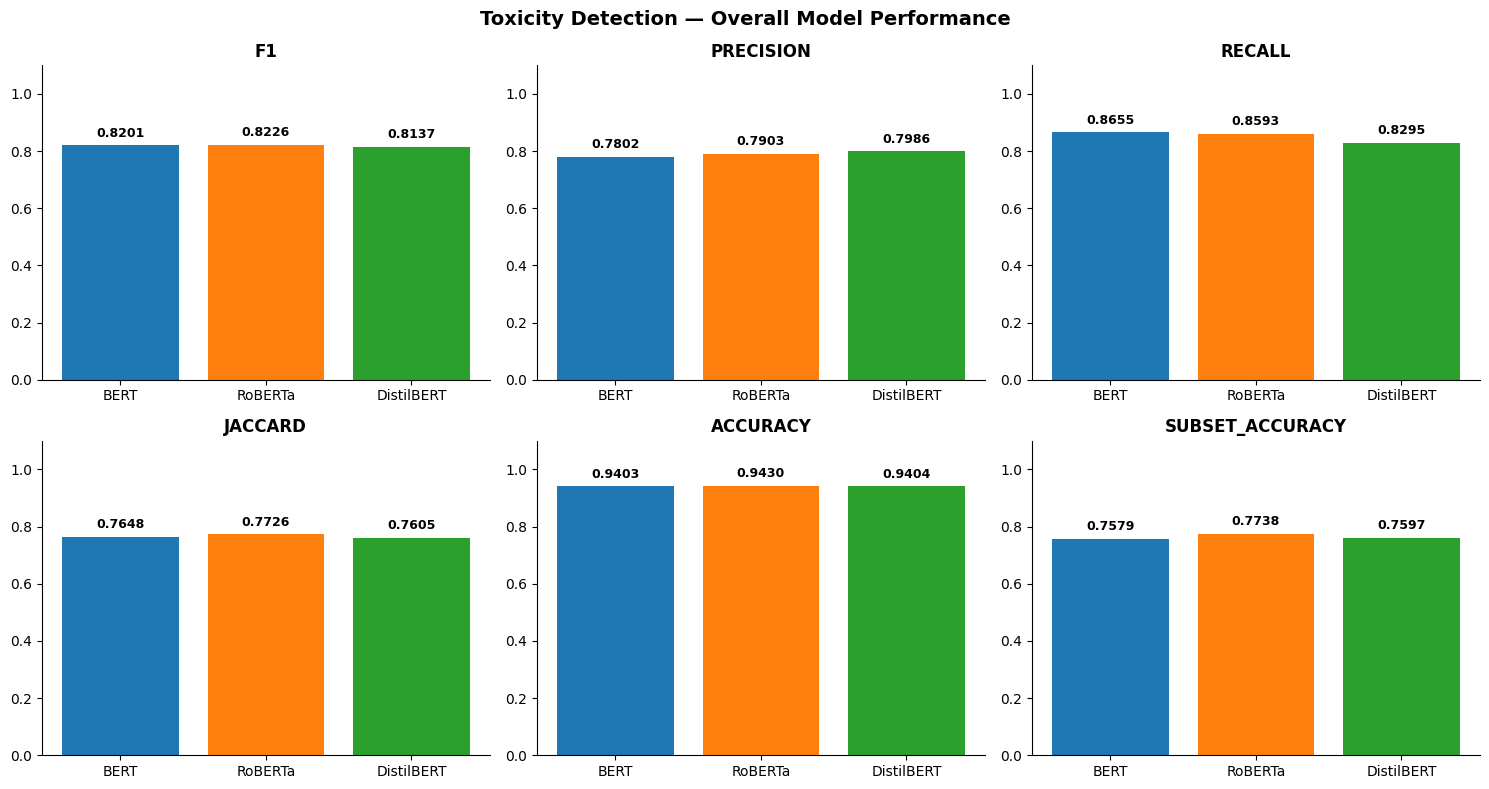

Saved: comparison_overall_metrics.png


In [14]:
# bar chart comparing all three models across 6 metrics
# saved as a PNG so we can include it in the thesis appendix or paper
metrics_to_plot = ['f1', 'precision', 'recall', 'jaccard', 'accuracy', 'subset_accuracy']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Harmful Text Detection — Overall Model Performance', fontsize=14, fontweight='bold')
for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = [results[m][metric] for m in models_list]
    bars = ax.bar(models_list, vals, color=colors)
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('./comparison_overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_overall_metrics.png')


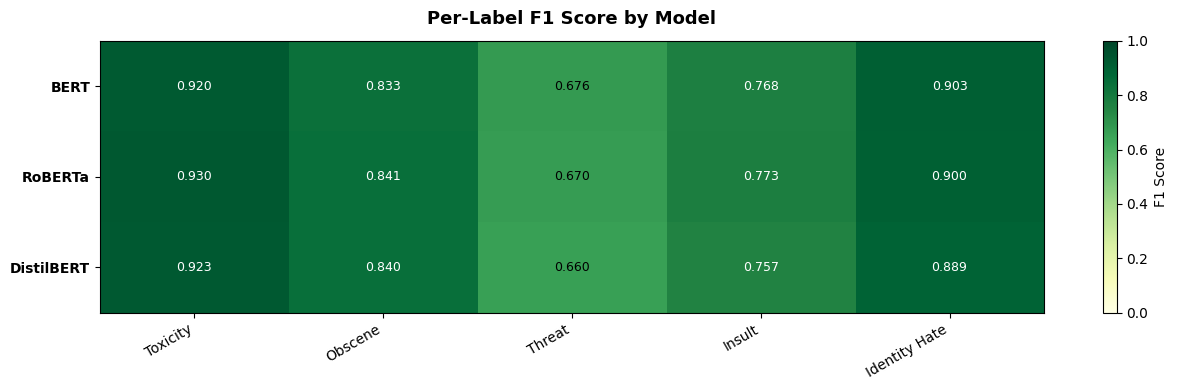

Saved: comparison_per_label_heatmap.png


In [15]:
# heatmap showing per-label F1 for each model
# makes it easy to spot which labels each model struggles with at a glance
labels_order = list(LABEL_SCHEMA.keys())
heatmap_data = np.array([[per_label_results[m][lbl] for lbl in labels_order] for m in models_list])

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_order)))
ax.set_xticklabels([l.replace('_', ' ').title() for l in labels_order], rotation=30, ha='right')
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list, fontweight='bold')
for i in range(len(models_list)):
    for j in range(len(labels_order)):
        ax.text(j, i, f'{heatmap_data[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='black' if heatmap_data[i,j] < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Label F1 Score by Model', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('./comparison_per_label_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_per_label_heatmap.png')


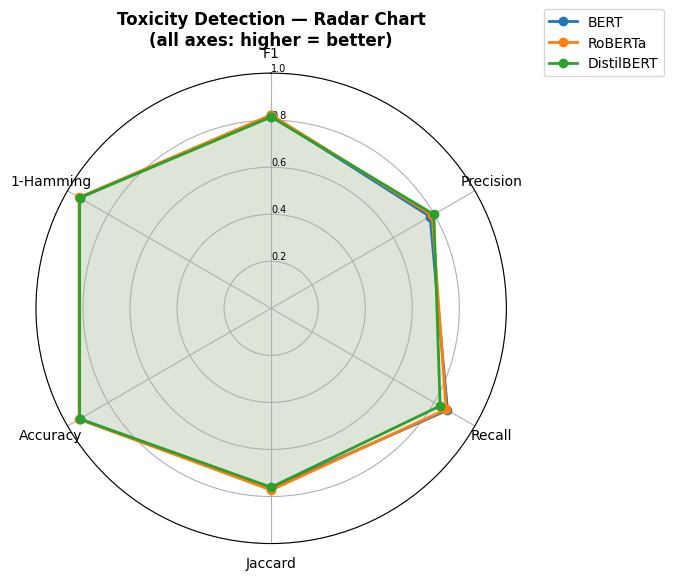

Saved: comparison_radar.png


In [16]:
# radar chart — good for visualizing tradeoffs across multiple metrics simultaneously
# hamming_loss is flipped to (1 - hamming) so higher is always better on all axes
radar_metrics_display = ['F1', 'Precision', 'Recall', 'Jaccard', 'Accuracy', '1-Hamming']
N = len(radar_metrics_display)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
plt.xticks(angles[:-1], radar_metrics_display, size=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax.set_ylim(0, 1)

radar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for model, color in zip(models_list, radar_colors):
    vals_r = [
        results[model]['f1'], results[model]['precision'], results[model]['recall'],
        results[model]['jaccard'], results[model]['accuracy'],
        1 - results[model]['hamming_loss'],
    ] + [results[model]['f1']]
    ax.plot(angles, vals_r, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals_r, alpha=0.08, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Harmful Text Detection — Radar Chart\n(all axes: higher = better)',
             size=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_radar.png')


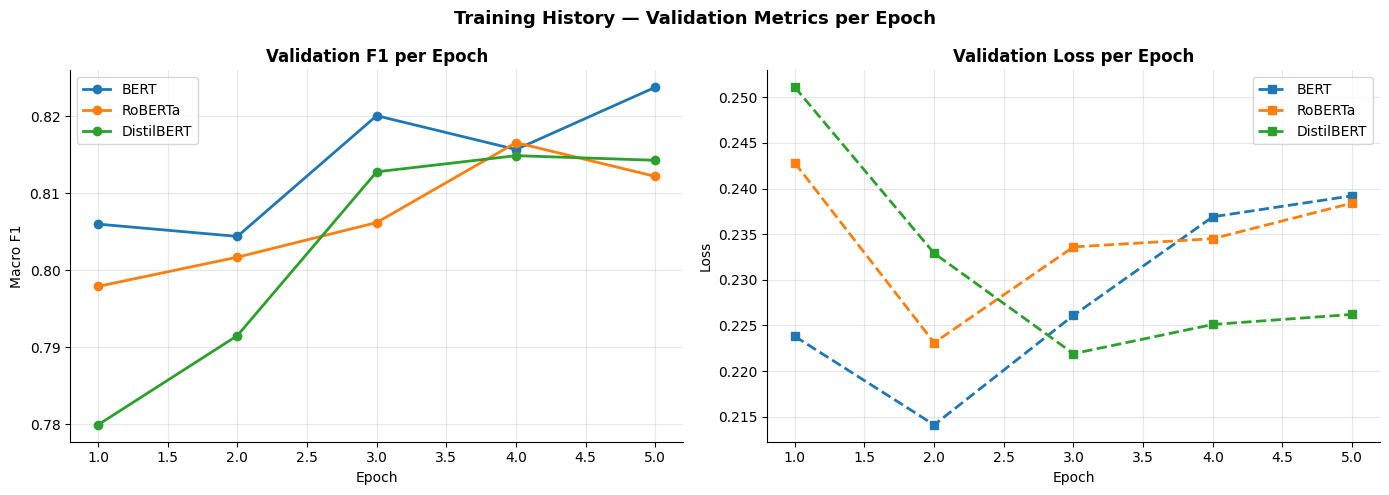

Saved: comparison_training_history.png

BEST TRAINED MODEL: RoBERTa  (F1 = 0.8226)
  ▲  f1                  : 0.8226
  ▲  precision           : 0.7903
  ▲  recall              : 0.8593
  ▲  jaccard             : 0.7726
  ▼  hamming_loss        : 0.0570
  ▲  accuracy            : 0.9430
  ▲  subset_accuracy     : 0.7738


In [17]:
# plots validation F1 and validation loss across epochs for all three models
# helps us see if any model overfit or stopped improving early
histories = {
    'BERT':       bert_result['training_history'],
    'RoBERTa':    roberta_result['training_history'],
    'DistilBERT': distilbert_result['training_history'],
}
history_colors = {'BERT': '#1f77b4', 'RoBERTa': '#ff7f0e', 'DistilBERT': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Validation Metrics per Epoch', fontsize=13, fontweight='bold')
for model_name_h, hist in histories.items():
    epoch_keys = sorted([k for k in hist if isinstance(k, int)])
    if not epoch_keys:
        continue
    f1_vals   = [hist[e]['eval_f1'] for e in epoch_keys]
    loss_vals = [hist[e]['eval_loss'] for e in epoch_keys]
    color = history_colors[model_name_h]
    axes[0].plot(epoch_keys, f1_vals,   'o-',  label=model_name_h, color=color, linewidth=2)
    axes[1].plot(epoch_keys, loss_vals, 's--', label=model_name_h, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation F1 per Epoch', 'Validation Loss per Epoch'],
    ['Macro F1', 'Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./comparison_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_training_history.png')

best_model = max(results, key=lambda m: results[m]['f1'])
print(f"\n{'='*60}")
print(f'BEST TRAINED MODEL: {best_model}  (F1 = {results[best_model]["f1"]:.4f})')
print(f"{'='*60}")
for metric, val in results[best_model].items():
    arrow = '▼' if metric == 'hamming_loss' else '▲'
    print(f'  {arrow}  {metric:<20}: {val:.4f}')


## 6b. Ensemble Benchmark

An ensemble is **not a separately trained model** — it averages the sigmoid
probabilities from the three already-trained models at inference time,
then applies F1-optimized thresholds on top of the averaged scores.

**Why it improves results:** each model makes different errors on the same input.
Averaging cancels out per-model noise, producing more stable confidence scores —
particularly for rare labels (`threat`, `identity_hate`) where individual
models are most uncertain. This is a standard variance-reduction technique.

Results are reported as a **benchmark comparison** alongside the three trained models.


In [18]:
# ensemble benchmark: average the sigmoid probabilities from all three models
# then find optimal thresholds on the averaged val probs
# this is not a separately trained model — it's just inference-time aggregation
#
# the intuition: each model makes different errors, so averaging cancels out noise
# especially useful for rare labels where individual models are uncertain
print('\n' + '='*60)
print('ENSEMBLE BENCHMARK: mean(BERT, RoBERTa, DistilBERT)')
print('='*60)

def get_probs(result, df, max_length=128):
    """Re-run predict on a split; return sigmoid probs and labels."""
    ds = make_hf_dataset(df, result['tokenizer'], max_length=max_length)
    out = result['trainer'].predict(ds)
    return torch.sigmoid(torch.tensor(out.predictions)).numpy(), out.label_ids.astype(int)

# Val set: find ensemble thresholds
print('Getting val set probs...')
b_vp, b_vl = get_probs(bert_result,       val_df)
r_vp, _    = get_probs(roberta_result,    val_df)
d_vp, _    = get_probs(distilbert_result, val_df)
ens_val_probs = (b_vp + r_vp + d_vp) / 3.0
ensemble_thresholds = find_optimal_thresholds_from_probs(ens_val_probs, b_vl)

# Test set: evaluate with ensemble thresholds
print('\nGetting test set probs...')
b_tp, b_tl = get_probs(bert_result,       test_df)
r_tp, _    = get_probs(roberta_result,    test_df)
d_tp, _    = get_probs(distilbert_result, test_df)
ens_test_probs = (b_tp + r_tp + d_tp) / 3.0

ens_preds = np.zeros_like(ens_test_probs, dtype=int)
for i, lbl in enumerate(LABEL_NAMES):
    ens_preds[:, i] = (ens_test_probs[:, i] > ensemble_thresholds.get(lbl, 0.5)).astype(int)

ensemble_test_metrics = {
    'f1':              float(f1_score(b_tl, ens_preds, average='macro', zero_division=0)),
    'precision':       float(precision_score(b_tl, ens_preds, average='macro', zero_division=0)),
    'recall':          float(recall_score(b_tl, ens_preds, average='macro', zero_division=0)),
    'jaccard':         float(jaccard_score(b_tl, ens_preds, average='micro', zero_division=0)),
    'hamming_loss':    float(hamming_loss(b_tl, ens_preds)),
    'accuracy':        float((ens_preds == b_tl).mean()),
    'subset_accuracy': float((ens_preds == b_tl).all(axis=1).mean()),
}
ensemble_per_label = compute_per_label_metrics(ens_test_probs, b_tl, ensemble_thresholds)

print('\nEnsemble test metrics:')
for k, v in ensemble_test_metrics.items():
    arrow = '▼' if k == 'hamming_loss' else '▲'
    print(f'  {arrow}  {k:<20}: {v:.4f}')
print('\nEnsemble per-label F1:')
for lbl, m in ensemble_per_label.items():
    print(f'  {lbl:<20} F1={m["f1"]:.4f}  P={m["precision"]:.4f}  R={m["recall"]:.4f}  t={m["threshold"]}')



ENSEMBLE BENCHMARK: mean(BERT, RoBERTa, DistilBERT)
Getting val set probs...


Map:   0%|          | 0/4341 [00:00<?, ? examples/s]

Map:   0%|          | 0/4341 [00:00<?, ? examples/s]

Map:   0%|          | 0/4341 [00:00<?, ? examples/s]


Finding F1-optimal thresholds on ensemble val probs...
  Label                 Threshold       F1  Precision   Recall
  ──────────────────────────────────────────────────────────
  toxicity                  0.600   0.9146     0.8869   0.9441
  obscene                   0.520   0.8584     0.8174   0.9037
  threat                    0.380   0.7200     0.6569   0.7965
  insult                    0.620   0.7688     0.7402   0.7996
  identity_hate             0.540   0.9055     0.8685   0.9458

Getting test set probs...


Map:   0%|          | 0/4341 [00:00<?, ? examples/s]

Map:   0%|          | 0/4341 [00:00<?, ? examples/s]

Map:   0%|          | 0/4341 [00:00<?, ? examples/s]


Ensemble test metrics:
  ▲  f1                  : 0.8278
  ▲  precision           : 0.7920
  ▲  recall              : 0.8709
  ▲  jaccard             : 0.7810
  ▼  hamming_loss        : 0.0542
  ▲  accuracy            : 0.9458
  ▲  subset_accuracy     : 0.7779

Ensemble per-label F1:
  toxicity             F1=0.9320  P=0.9148  R=0.9499  t=0.6
  obscene              F1=0.8415  P=0.8096  R=0.8760  t=0.52
  threat               F1=0.6783  P=0.5909  R=0.7959  t=0.38
  insult               F1=0.7777  P=0.7625  R=0.7935  t=0.62
  identity_hate        F1=0.9098  P=0.8824  R=0.9389  t=0.54



FULL COMPARISON: trained models vs ensemble benchmark
                Model       f1  precision   recall  jaccard  hamming_loss  accuracy  subset_accuracy
                 BERT 0.820096   0.780170 0.865470 0.764759      0.059664  0.940336         0.757890
              RoBERTa 0.822593   0.790326 0.859254 0.772568      0.056991  0.943009         0.773785
           DistilBERT 0.813667   0.798611 0.829450 0.760467      0.059572  0.940428         0.759733
Ensemble\n(benchmark) 0.827849   0.792027 0.870864 0.780983      0.054227  0.945773         0.777931


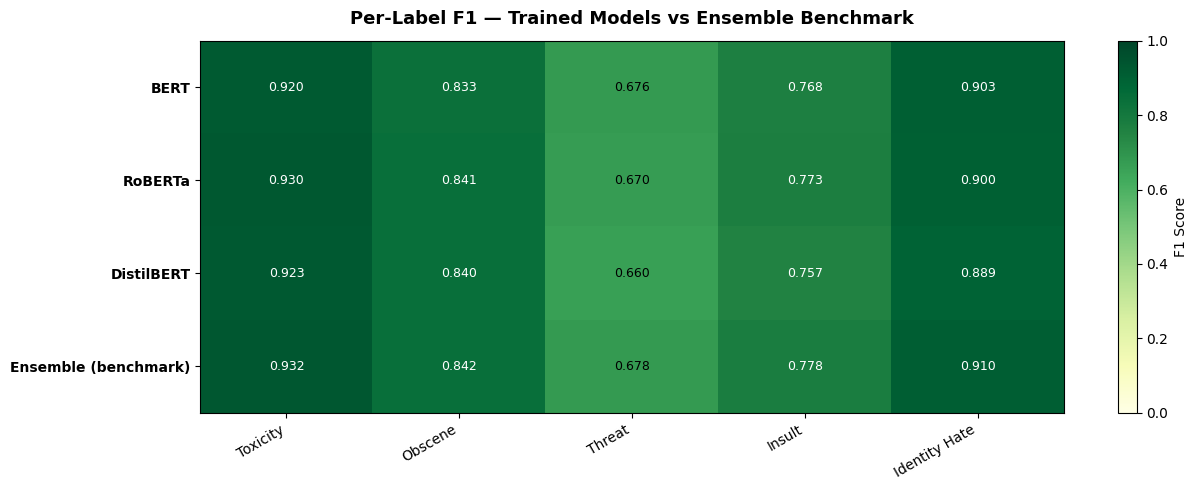

Saved: comparison_per_label_heatmap_with_ensemble.png

Note: primary charts (comparison_overall_metrics.png, comparison_radar.png) show
      trained models only. This heatmap is the ensemble benchmark comparison.


In [19]:
# add the ensemble as a fourth row in the comparison table and heatmap
# clearly labeled as a benchmark so it's not confused with a trained model
results_with_ens = dict(results)  # copy — does NOT modify the 3-model results dict
results_with_ens['Ensemble\n(benchmark)'] = ensemble_test_metrics
per_label_with_ens = dict(per_label_results)
per_label_with_ens['Ensemble\n(benchmark)'] = {lbl: m['f1'] for lbl, m in ensemble_per_label.items()}
all_models_bench = list(results_with_ens.keys())

comp_df = pd.DataFrame(results_with_ens).T.reset_index().rename(columns={'index': 'Model'})
print('\n' + '='*110)
print('FULL COMPARISON: trained models vs ensemble benchmark')
print('='*110)
print(comp_df.to_string(index=False))

# Heatmap with ensemble row added
labels_order = list(LABEL_SCHEMA.keys())
hmap_data = np.array([[per_label_with_ens[m][lbl] for lbl in labels_order] for m in all_models_bench])
row_labels = [m.replace('\n', ' ') for m in all_models_bench]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(hmap_data, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_order)))
ax.set_xticklabels([l.replace('_', ' ').title() for l in labels_order], rotation=30, ha='right')
ax.set_yticks(range(len(all_models_bench)))
ax.set_yticklabels(row_labels, fontweight='bold')
for i in range(len(all_models_bench)):
    for j in range(len(labels_order)):
        ax.text(j, i, f'{hmap_data[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='black' if hmap_data[i,j] < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Label F1 — Trained Models vs Ensemble Benchmark',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('./comparison_per_label_heatmap_with_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_per_label_heatmap_with_ensemble.png')
print('\nNote: primary charts (comparison_overall_metrics.png, comparison_radar.png) show')
print('      trained models only. This heatmap is the ensemble benchmark comparison.')


## 7. Save All Models + Rich Metrics + Visualizations → ZIP


In [20]:
# saves all three trained models to disk: weights, tokenizer, metrics.json,
# config.pkl (thresholds + label schema), and a human-readable model_summary.txt
#
# also copies all visualization PNGs into the models/ folder
# and saves comparison_results.json with all three models + ensemble benchmark
#
# at the end, zips the whole models/ directory for easy download from Colab/Kaggle
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

for model_key, (result, hf_name, folder_name) in all_results_map.items():
    save_path = os.path.join(models_dir, folder_name)
    os.makedirs(save_path, exist_ok=True)
    result['trainer'].save_model(save_path)
    result['tokenizer'].save_pretrained(save_path)
    with open(os.path.join(save_path, 'metrics.json'), 'w') as f:
        json_lib.dump(result['rich_metrics'], f, indent=2)
    joblib.dump({
        'model_name':      hf_name,
        'model_type':      model_key,
        'num_labels':      NUM_LABELS,
        'test_metrics':    result['test_metrics'],
        'label_schema':    LABEL_SCHEMA,
        'reverse_schema':  {str(k): v for k, v in REVERSE_LABEL_SCHEMA.items()},
        'best_thresholds': result['best_thresholds'],
    }, os.path.join(save_path, 'config.pkl'))
    with open(os.path.join(save_path, 'model_summary.txt'), 'w') as f:
        f.write(f'Toxicity Detection Model — {hf_name}\n')
        f.write('='*60 + '\n\n')
        f.write(f'Folder    : {folder_name}\n')
        f.write(f'HF ID     : {hf_name}\n')
        f.write(f'Num labels: {NUM_LABELS}\n')
        f.write(f'Labels    : {LABEL_NAMES}\n\n')
        f.write('Test Metrics (tuned thresholds):\n')
        for k, v in result['test_metrics'].items():
            f.write(f'  {k:<20}: {v:.4f}\n')
        f.write('\nPer-Label Detail:\n')
        for lbl, m in result['per_label_detail'].items():
            f.write(f'  {lbl:<20}: F1={m["f1"]:.4f}  P={m["precision"]:.4f}  R={m["recall"]:.4f}  t={m["threshold"]}\n')
        f.write('\nBest Thresholds:\n')
        for lbl, t in result['best_thresholds'].items():
            f.write(f'  {lbl:<20}: {t:.3f}\n')
        f.write(f'\nTrain time: {result["train_time_min"]:.1f} min\n')
    print(f'Saved: {folder_name}/ (weights + metrics.json + config.pkl + model_summary.txt)')

viz_files = [
    'comparison_overall_metrics.png',
    'comparison_per_label_heatmap.png',
    'comparison_radar.png',
    'comparison_training_history.png',
    'comparison_per_label_heatmap_with_ensemble.png',
]
for viz in viz_files:
    if os.path.exists(viz):
        shutil.copy(viz, os.path.join(models_dir, viz))
        print(f'Copied: {viz}')

comparison_out = {}
for model_key, (result, hf_name, folder_name) in all_results_map.items():
    comparison_out[folder_name] = {
        'model_name':      hf_name,
        'test_metrics':    result['test_metrics'],
        'per_label_f1':    result['per_label_metrics'],
        'best_thresholds': result['best_thresholds'],
        'rich_metrics':    result['rich_metrics'],
    }
comparison_out['ensemble_benchmark'] = {
    'note':            'Not a trained model. Mean probability of BERT + RoBERTa + DistilBERT.',
    'components':      ['bert', 'roberta', 'distilbert'],
    'aggregation':     'mean_probability',
    'test_metrics':    ensemble_test_metrics,
    'per_label_f1':    {lbl: m['f1'] for lbl, m in ensemble_per_label.items()},
    'best_thresholds': {k: round(v, 3) for k, v in ensemble_thresholds.items()},
}
with open(os.path.join(models_dir, 'comparison_results.json'), 'w') as f:
    json_lib.dump(comparison_out, f, indent=2)
print('Saved: comparison_results.json (3 models + ensemble_benchmark entry)')

print('\nmodels/ structure:')
for root, dirs, files in os.walk(models_dir):
    level = root.replace(models_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = '  ' * (level + 1)
        for fname in sorted(files):
            fsize = os.path.getsize(os.path.join(root, fname))
            size_label = f'{fsize/1024:.1f} KB' if fsize < 1_048_576 else f'{fsize/1048576:.1f} MB'
            print(f'{subindent}{fname}  [{size_label}]')

zip_path = './models_export'
if os.path.exists(zip_path + '.zip'):
    os.remove(zip_path + '.zip')
shutil.make_archive(zip_path, 'zip', '.', 'models')
zip_size = os.path.getsize(zip_path + '.zip') / 1048576
print(f'\nZipped: models_export.zip  ({zip_size:.1f} MB)')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: bert/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: roberta/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: distilbert/ (weights + metrics.json + config.pkl + model_summary.txt)
Copied: comparison_overall_metrics.png
Copied: comparison_per_label_heatmap.png
Copied: comparison_radar.png
Copied: comparison_training_history.png
Copied: comparison_per_label_heatmap_with_ensemble.png
Saved: comparison_results.json (3 models + ensemble_benchmark entry)

models/ structure:
models/
  comparison_overall_metrics.png  [81.0 KB]
  comparison_per_label_heatmap.png  [66.6 KB]
  comparison_per_label_heatmap_with_ensemble.png  [83.8 KB]
  comparison_radar.png  [145.0 KB]
  comparison_results.json  [17.0 KB]
  comparison_training_history.png  [131.5 KB]
  roberta/
    config.json  [0.9 KB]
    config.pkl  [0.5 KB]
    metrics.json  [4.2 KB]
    model.safetensors  [475.5 MB]
    model_summary.txt  [1.0 KB]
    tokenizer.json  [3.4 MB]
    tokenizer_config.json  [0.4 KB]
    training_args.bin  [5.1 KB]
  distilbert/
    config.json  [0.9 KB]
    config.pkl  [0.6 KB]
    metrics.json  [3.4 KB]
    model.

## 8. Inference — All Models with Tuned Thresholds

INFERENCE — 10 runs × 5 samples

 LOADING: BERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0040  
    obscene              0.0028  
    threat               0.0032  
    insult               0.0023  
    identity_hate        0.0030  

  [FLAGGED] You are so stupid and worthless!
  Labels: ['toxicity', 'obscene', 'insult']  Risk: 0.9837
    toxicity             0.9811  ███████████████████
    obscene              0.6538  █████████████
    threat               0.0158  
    insult               0.9837  ███████████████████
    identity_hate        0.0108  

  [FLAGGED] I hate people from that country.
  Labels: ['toxicity', 'insult', 'identity_hate']  Risk: 0.9952
    toxicity             0.9952  ███████████████████
    obscene              0.0158  
    threat               0.0235  
    insult               0.7061  ██████████████
    identity_hate        0.9928  ███████████████████

  [FLAGGED] I am going to hurt you, watch your back.
  Labels: ['toxicity', 'threat']  Risk: 0.9655
    toxicity      

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0029  
    obscene              0.0031  
    threat               0.0039  
    insult               0.0039  
    identity_hate        0.0038  

  [FLAGGED] You are so stupid and worthless!
  Labels: ['toxicity', 'insult']  Risk: 0.9846
    toxicity             0.9846  ███████████████████
    obscene              0.1780  ███
    threat               0.0237  
    insult               0.9761  ███████████████████
    identity_hate        0.0100  

  [FLAGGED] I hate people from that country.
  Labels: ['toxicity', 'identity_hate']  Risk: 0.9946
    toxicity             0.9756  ███████████████████
    obscene              0.0074  
    threat               0.0164  
    insult               0.1886  ███
    identity_hate        0.9946  ███████████████████

  [FLAGGED] I am going to hurt you, watch your back.
  Labels: ['toxicity', 'threat']  Risk: 0.9903
    toxicity             0.9039  ██████████████████
    obsc

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0070  
    obscene              0.0037  
    threat               0.0023  
    insult               0.0033  
    identity_hate        0.0024  

  [FLAGGED] You are so stupid and worthless!
  Labels: ['toxicity', 'insult']  Risk: 0.9746
    toxicity             0.9746  ███████████████████
    obscene              0.3457  ██████
    threat               0.0145  
    insult               0.9544  ███████████████████
    identity_hate        0.0343  

  [FLAGGED] I hate people from that country.
  Labels: ['toxicity', 'identity_hate']  Risk: 0.9575
    toxicity             0.9568  ███████████████████
    obscene              0.0042  
    threat               0.0131  
    insult               0.5093  ██████████
    identity_hate        0.9575  ███████████████████

  [FLAGGED] I am going to hurt you, watch your back.
  Labels: ['toxicity', 'threat']  Risk: 0.9738
    toxicity             0.9358  █████████████████

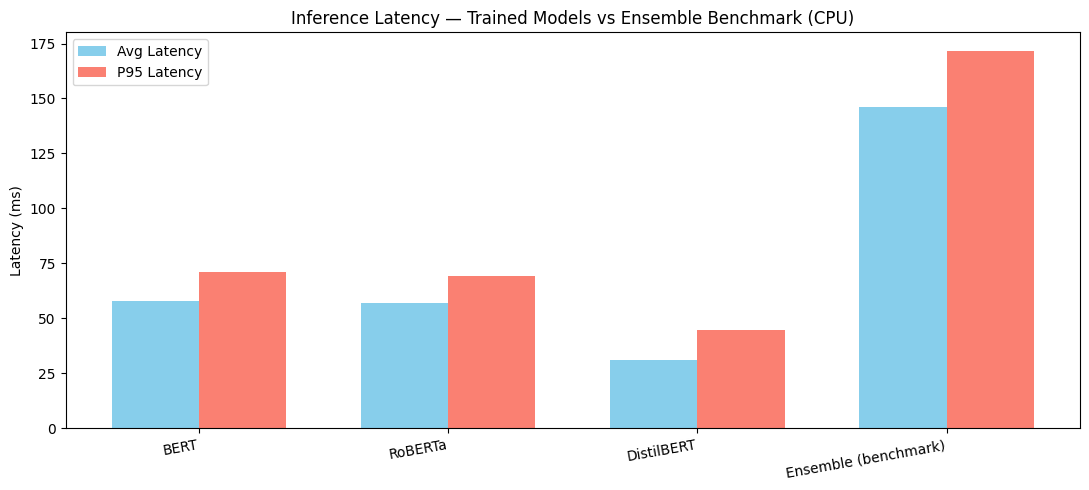

Saved: models/comparison_inference_latency.png

ACCURACY vs SPEED — TRAINED MODELS
Model                F1  Precision   Recall   Avg ms
----------------------------------------------------
BERT             0.8201     0.7802   0.8655     57.7
RoBERTa          0.8226     0.7903   0.8593     57.1
DistilBERT       0.8137     0.7986   0.8295     31.3

Ensemble (benchmark): F1=0.8278  Precision=0.7920  Avg latency=146.2 ms


In [21]:
# inference functions: run_inference for a single model, run_ensemble_inference for all three
# both clean the text first, then return: is_flagged, detected labels, per-label scores, risk score
#
# we run N_RUNS=10 passes on 5 sample texts to get stable latency estimates
# results include avg ms, min, max, and p95 — p95 matters more than avg in production
timing_models = {
    'BERT':       os.path.join(models_dir, 'bert'),
    'RoBERTa':    os.path.join(models_dir, 'roberta'),
    'DistilBERT': os.path.join(models_dir, 'distilbert'),
}

timing_samples = [
    'This is a great product! Highly recommend.',
    'You are so stupid and worthless!',
    'I hate people from that country.',
    'I am going to hurt you, watch your back.',
    "Let's grab coffee sometime!",
]


def run_inference(text, model, tokenizer, config, max_length=128):
    """Single-model inference with per-label thresholds from config."""
    model.eval()
    preprocessor = TextPreprocessor()
    cleaned = preprocessor.clean_text(text)
    inputs = tokenizer(cleaned, return_tensors='pt',
                       truncation=True, max_length=max_length, padding=True)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.sigmoid(logits).squeeze().tolist()
    thresholds = config.get('best_thresholds', {})
    reverse    = config['reverse_schema']
    scores  = {reverse[str(i)]: round(p, 4) for i, p in enumerate(probs)}
    flagged = [lbl for lbl, s in scores.items() if s >= thresholds.get(lbl, 0.5)]
    return {'is_flagged': len(flagged) > 0, 'labels': flagged,
            'scores': scores, 'risk_score': round(max(probs), 4)}


def run_ensemble_inference(text, loaded_models, thresholds, max_length=128):
    """
    Ensemble inference: average sigmoid probs from 3 loaded models,
    apply ensemble_thresholds. No separately trained model involved.
    """
    preprocessor = TextPreprocessor()
    cleaned = preprocessor.clean_text(text)
    all_probs = []
    for model, tokenizer in loaded_models:
        model.eval()
        inputs = tokenizer(cleaned, return_tensors='pt',
                           truncation=True, max_length=max_length, padding=True)
        with torch.no_grad():
            logits = model(**inputs).logits
        all_probs.append(torch.sigmoid(logits).squeeze().tolist())
    avg_probs = [sum(p[i] for p in all_probs) / len(all_probs) for i in range(NUM_LABELS)]
    reverse = {str(i): lbl for i, lbl in enumerate(LABEL_NAMES)}
    scores  = {reverse[str(i)]: round(p, 4) for i, p in enumerate(avg_probs)}
    flagged = [lbl for lbl, s in scores.items() if s >= thresholds.get(lbl, 0.5)]
    return {'is_flagged': len(flagged) > 0, 'labels': flagged,
            'scores': scores, 'risk_score': round(max(avg_probs), 4)}


N_RUNS = 10
timing_summary = {}
loaded_for_ensemble = []

print('=' * 70)
print(f'INFERENCE — {N_RUNS} runs × {len(timing_samples)} samples')
print('=' * 70)

for model_label, model_path in timing_models.items():
    print(f'\n{"="*70}\n LOADING: {model_label}\n{"="*70}')
    config    = joblib.load(os.path.join(model_path, 'config.pkl'))
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model_inf = AutoModelForSequenceClassification.from_pretrained(model_path)
    loaded_for_ensemble.append((model_inf, tokenizer))

    for text in timing_samples:
        res = run_inference(text, model_inf, tokenizer, config)
        status = 'FLAGGED' if res['is_flagged'] else 'CLEAN'
        print(f'\n  [{status}] {text[:60]}')
        if res['is_flagged']:
            print(f'  Labels: {res["labels"]}  Risk: {res["risk_score"]}')
        for lbl, s in res['scores'].items():
            bar = chr(9608) * int(s * 20)
            print(f'    {lbl:<20} {s:.4f}  {bar}')

    run_inference('warmup', model_inf, tokenizer, config)
    times = []
    for _ in range(N_RUNS):
        for text in timing_samples:
            t0 = time.perf_counter()
            run_inference(text, model_inf, tokenizer, config)
            times.append((time.perf_counter() - t0) * 1000)
    timing_summary[model_label] = {
        'avg_ms': sum(times)/len(times), 'min_ms': min(times),
        'max_ms': max(times), 'p95_ms': float(np.percentile(times, 95))
    }
    t = timing_summary[model_label]
    print(f'  Latency — avg: {t["avg_ms"]:.2f} ms | p95: {t["p95_ms"]:.2f} ms')

# Ensemble demo
print(f'\n{"="*70}\n ENSEMBLE BENCHMARK INFERENCE (mean of 3 models)\n{"="*70}')
for text in timing_samples:
    res = run_ensemble_inference(text, loaded_for_ensemble, ensemble_thresholds)
    status = 'FLAGGED' if res['is_flagged'] else 'CLEAN'
    print(f'\n  [{status}] {text[:60]}')
    if res['is_flagged']:
        print(f'  Labels: {res["labels"]}  Risk: {res["risk_score"]}')
    for lbl, s in res['scores'].items():
        bar = chr(9608) * int(s * 20)
        print(f'    {lbl:<20} {s:.4f}  {bar}')

run_ensemble_inference('warmup', loaded_for_ensemble, ensemble_thresholds)
ens_times = []
for _ in range(N_RUNS):
    for text in timing_samples:
        t0 = time.perf_counter()
        run_ensemble_inference(text, loaded_for_ensemble, ensemble_thresholds)
        ens_times.append((time.perf_counter() - t0) * 1000)
timing_summary['Ensemble (benchmark)'] = {
    'avg_ms': sum(ens_times)/len(ens_times), 'min_ms': min(ens_times),
    'max_ms': max(ens_times), 'p95_ms': float(np.percentile(ens_times, 95))
}
t = timing_summary['Ensemble (benchmark)']
print(f'  Ensemble latency — avg: {t["avg_ms"]:.2f} ms | p95: {t["p95_ms"]:.2f} ms')
print('  (Ensemble latency = sum of 3 model latencies; expected ~3x single model)')

# Latency chart
fig, ax = plt.subplots(figsize=(11, 5))
models_t = list(timing_summary.keys())
avgs = [timing_summary[m]['avg_ms'] for m in models_t]
p95s = [timing_summary[m]['p95_ms'] for m in models_t]
x = np.arange(len(models_t))
width = 0.35
ax.bar(x - width/2, avgs, width, label='Avg Latency', color='skyblue')
ax.bar(x + width/2, p95s, width, label='P95 Latency', color='salmon')
ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency — Trained Models vs Ensemble Benchmark (CPU)')
ax.set_xticks(x)
ax.set_xticklabels(models_t, rotation=10, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_inference_latency.png'), dpi=150)
plt.show()
print('Saved: models/comparison_inference_latency.png')

print('\n' + '='*70)
print('ACCURACY vs SPEED — TRAINED MODELS')
print('='*70)
print(f'{"Model":<14} {"F1":>8} {"Precision":>10} {"Recall":>8} {"Avg ms":>8}')
print('-' * 52)
for m in models_list:  # 3 trained models only
    r  = results[m]
    ms = timing_summary.get(m, {}).get('avg_ms', 0)
    print(f'{m:<14} {r["f1"]:>8.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {ms:>8.1f}')
print(f'\nEnsemble (benchmark): F1={ensemble_test_metrics["f1"]:.4f}  '
      f'Precision={ensemble_test_metrics["precision"]:.4f}  '
      f'Avg latency={timing_summary["Ensemble (benchmark)"]["avg_ms"]:.1f} ms')


## 9. Platform Surface Test — Best Model

Runs the best-performing trained model against realistic examples from all four platform surfaces.
Shows per-case pass/fail, detected labels, and confidence scores.

Surfaces: **Job Post · Profile · Proposal · Message**

In [22]:
# platform surface test: runs the best trained model on realistic examples
# from all four surfaces in the app — job posts, profiles, proposals, messages
#
# for each case we show: expected label, detected label, pass/fail, and a score bar chart
# the summary at the end breaks down accuracy per surface and reports FP/FN counts
# this is what we'd show in the thesis demo to prove the model works in context
model_order = ['BERT', 'RoBERTa', 'DistilBERT']
best_idx    = model_order.index(best_model)
bm_model, bm_tok = loaded_for_ensemble[best_idx]
bm_cfg = joblib.load(os.path.join(timing_models[best_model], 'config.pkl'))

print('=' * 70)
print(f'  PLATFORM SURFACE TEST   model: {best_model}')
print('=' * 70)

# (surface, description, text, expected_toxic, expected_labels)
test_cases = [
    # ── JOB POST ──────────────────────────────────────────────────────────
    ('JOB POST', 'Clean job post',
     'We are looking for an experienced Python developer for a 3-month remote contract. Strong communication and testing skills required.',
     False, []),
    ('JOB POST', 'Insult toward applicants',
     'Only serious developers should apply. We are tired of dealing with incompetent freelancers who cannot follow a simple brief.',
     True,  ['insult', 'toxicity']),
    ('JOB POST', 'Discriminatory hiring',
     'This role is only open to local candidates. We do not hire foreign workers because they always create problems and miss deadlines.',
     True,  ['identity_hate', 'toxicity']),
    ('JOB POST', 'Threat to freelancer',
     'Meet every deadline without exception. Miss one and we will make sure your reputation on this platform is destroyed.',
     True,  ['threat', 'toxicity']),

    # ── PROFILE ───────────────────────────────────────────────────────────
    ('PROFILE', 'Clean profile bio',
     'Full-stack developer with 6 years of experience in React and Django. I specialise in building clean, maintainable code for startups.',
     False, []),
    ('PROFILE', 'Obscene + insult toward clients',
     'I am the best developer on this platform, period. If you are too cheap to pay my rate then you do not deserve quality work. I have destroyed the reputation of clients who tried to lowball me.',
     True,  ['insult', 'toxicity']),
    ('PROFILE', 'Threat toward clients',
     'I will destroy anyone who tries to lowball me or steal my work. The last client who screwed me over found out exactly what happens when you cross me.',
     True,  ['threat', 'toxicity']),

    # ── PROPOSAL ──────────────────────────────────────────────────────────
    ('PROPOSAL', 'Clean proposal',
     'I have carefully reviewed your project requirements and believe my three years of experience in this domain makes me an excellent fit.',
     False, []),
    ('PROPOSAL', 'Insult toward client brief',
     'Your project brief is so poorly written it is clear you have absolutely no idea what you actually need. Have you considered hiring a consultant first?',
     True,  ['insult', 'toxicity']),
    ('PROPOSAL', 'Threat if not selected',
     'You would be making a serious mistake not hiring me. The last client who rejected me found out the hard way why I was the right choice.',
     True,  ['threat', 'toxicity']),
    ('PROPOSAL', 'Identity hate toward client',
     'I see from your profile where you are from. I have worked with your type before and you people always find a way to disappoint your contractors.',
     True,  ['identity_hate', 'toxicity']),

    # ── MESSAGE ───────────────────────────────────────────────────────────
    ('MESSAGE', 'Clean follow-up message',
     'Hi, just wanted to follow up on the deliverable we discussed. Are we still on track for the Friday deadline?',
     False, []),
    ('MESSAGE', 'Identity hate in message',
     'I am not paying someone like you. Your kind always scams people and then disappears. Go back to where you came from.',
     True,  ['identity_hate', 'toxicity']),
    ('MESSAGE', 'Obscene + insult — client venting',
     'You are an absolute piece of garbage. This is the worst work I have ever seen in my life, you should be ashamed to call yourself a developer.',
     True,  ['insult', 'obscene', 'toxicity']),
    ('MESSAGE', 'Threat — payment dispute',
     'Pay me the full amount by tomorrow or I will report you on every platform I can find and make sure everyone knows what kind of client you are.',
     True,  ['threat', 'toxicity']),
    ('MESSAGE', 'Escalated threat + insult',
     'I will ruin you. I will contact every client you have ever worked with and tell them what a fraud you are. Pay me now or this gets much worse.',
     True,  ['insult', 'threat', 'toxicity']),
]

# ── Run all inferences ────────────────────────────────────────────────────
run_data = []
for surface, desc, text, exp_toxic, exp_labels in test_cases:
    res     = run_inference(text, bm_model, bm_tok, bm_cfg)
    correct = (res['is_flagged'] == exp_toxic)
    run_data.append(dict(surface=surface, desc=desc, text=text,
                         exp_toxic=exp_toxic, exp_labels=exp_labels,
                         res=res, correct=correct))

# ── Display ───────────────────────────────────────────────────────────────
BAR = 20
cur_surface = None
for d in run_data:
    if d['surface'] != cur_surface:
        cur_surface = d['surface']
        print(f'\n{"─" * 68}')
        print(f'  {cur_surface}')
        print(f'{"─" * 68}')

    verdict   = 'FLAGGED' if d['res']['is_flagged'] else 'CLEAN'
    sym       = '[PASS]' if d['correct'] else '[FAIL]'
    predicted = d['res']['labels']
    exp_lbl   = d['exp_labels']
    missed    = set(exp_lbl) - set(predicted)
    extra     = set(predicted) - set(exp_lbl)

    print(f'\n  {sym} {d["desc"]}  →  {verdict}')
    print(f'  Text     : "{d["text"][:78]}{"..." if len(d["text"]) > 78 else ""}"')
    print(f'  Expected : {", ".join(exp_lbl) if exp_lbl else "none (clean)"}')
    print(f'  Detected : {", ".join(predicted) if predicted else "none"}')
    if missed: print(f'  Missed   : {", ".join(missed)}')
    if extra:  print(f'  Extra    : {", ".join(extra)}')
    print(f'  Scores:')
    for lbl, score in sorted(d['res']['scores'].items(), key=lambda x: -x[1]):
        filled = chr(0x2588) * int(score * BAR)
        empty  = chr(0x2591) * (BAR - int(score * BAR))
        print(f'    {lbl:<20} {score:.4f}  {filled}{empty}')

# ── Summary ───────────────────────────────────────────────────────────────
total   = len(run_data)
correct = sum(1 for d in run_data if d['correct'])
n_toxic_cases = sum(1 for d in run_data if d['exp_toxic'])
n_clean_cases = total - n_toxic_cases
fp = sum(1 for d in run_data if not d['exp_toxic'] and d['res']['is_flagged'])
fn = sum(1 for d in run_data if d['exp_toxic'] and not d['res']['is_flagged'])

by_surface = {}
for d in run_data:
    s = d['surface']
    if s not in by_surface:
        by_surface[s] = {'correct': 0, 'total': 0}
    by_surface[s]['total']   += 1
    by_surface[s]['correct'] += int(d['correct'])

print(f'\n{"=" * 68}')
print(f'  SUMMARY   model: {best_model}')
print(f'{"=" * 68}')
print(f'  Total test cases       : {total}')
print(f'  Correctly classified   : {correct} / {total}  ({correct/total*100:.0f}%)')
print(f'  False positives (clean text flagged) : {fp}')
print(f'  False negatives (toxic text missed)  : {fn}')
print(f'{"─" * 68}')
print(f'  {"Surface":<14} {"Pass":>5} {"Total":>6}  {"Bar"}')
print(f'{"─" * 68}')
for surf, r in by_surface.items():
    bar  = chr(0x2588) * r['correct'] + chr(0x2591) * (r['total'] - r['correct'])
    pct  = r['correct'] / r['total'] * 100
    print(f'  {surf:<14} {r["correct"]:>5} / {r["total"]:<4}  {bar}  ({pct:.0f}%)')
print(f'{"=" * 68}')


  PLATFORM SURFACE TEST   model: RoBERTa

────────────────────────────────────────────────────────────────────
  JOB POST
────────────────────────────────────────────────────────────────────

  [PASS] Clean job post  →  CLEAN
  Text     : "We are looking for an experienced Python developer for a 3-month remote contra..."
  Expected : none (clean)
  Detected : none
  Scores:
    threat               0.0055  ░░░░░░░░░░░░░░░░░░░░
    toxicity             0.0044  ░░░░░░░░░░░░░░░░░░░░
    identity_hate        0.0039  ░░░░░░░░░░░░░░░░░░░░
    insult               0.0035  ░░░░░░░░░░░░░░░░░░░░
    obscene              0.0026  ░░░░░░░░░░░░░░░░░░░░

  [FAIL] Insult toward applicants  →  CLEAN
  Text     : "Only serious developers should apply. We are tired of dealing with incompetent..."
  Expected : insult, toxicity
  Detected : none
  Missed   : insult, toxicity
  Scores:
    insult               0.4405  ████████░░░░░░░░░░░░
    toxicity             0.3762  ███████░░░░░░░░░░░░░
    threat     

## 10. Final ZIP 


In [23]:
# final zip — rebuilds models_export.zip with everything included
# run this cell last if you've re-evaluated or added anything after the main training run
zip_path = './models_export'
if os.path.exists(zip_path + '.zip'):
    os.remove(zip_path + '.zip')
shutil.make_archive(zip_path, 'zip', '.', 'models')
zip_size = os.path.getsize(zip_path + '.zip') / 1048576

print('\n' + '='*70 + '\nTRAINING COMPLETE\n' + '='*70)
print(f'\nAll outputs saved in: {models_dir}/')
print(f'  models_export.zip  ({zip_size:.1f} MB)')
print(f'\nBest trained model: {best_model}  (F1 = {results[best_model]["f1"]:.4f})')
print(f'Ensemble benchmark: F1 = {ensemble_test_metrics["f1"]:.4f}')
print('\nZIP contains:')
print('  bert/                                        — weights, metrics.json, config.pkl, model_summary.txt')
print('  roberta/                                     — weights, metrics.json, config.pkl, model_summary.txt')
print('  distilbert/                                  — weights, metrics.json, config.pkl, model_summary.txt')
print('  comparison_results.json                      — 3 models + ensemble_benchmark entry')
print('  comparison_overall_metrics.png               — 3 trained models')
print('  comparison_per_label_heatmap.png             — 3 trained models')
print('  comparison_per_label_heatmap_with_ensemble.png — incl. ensemble benchmark row')
print('  comparison_radar.png                         — 3 trained models')
print('  comparison_training_history.png              — 3 trained models')
print('  comparison_inference_latency.png             — all 4 incl. ensemble benchmark')



TRAINING COMPLETE

All outputs saved in: ./models/
  models_export.zip  (1058.7 MB)

Best trained model: RoBERTa  (F1 = 0.8226)
Ensemble benchmark: F1 = 0.8278

ZIP contains:
  bert/                                        — weights, metrics.json, config.pkl, model_summary.txt
  roberta/                                     — weights, metrics.json, config.pkl, model_summary.txt
  distilbert/                                  — weights, metrics.json, config.pkl, model_summary.txt
  comparison_results.json                      — 3 models + ensemble_benchmark entry
  comparison_overall_metrics.png               — 3 trained models
  comparison_per_label_heatmap.png             — 3 trained models
  comparison_per_label_heatmap_with_ensemble.png — incl. ensemble benchmark row
  comparison_radar.png                         — 3 trained models
  comparison_training_history.png              — 3 trained models
  comparison_inference_latency.png             — all 4 incl. ensemble benchmark
